## 1. Setup & Imports

In [12]:
!pip install -q ucimlrepo

In [13]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import warnings
import torch
import torch.nn as nn
from torch.autograd import Variable
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from numpy.linalg import svd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

warnings.filterwarnings('ignore')
np.set_printoptions(suppress=True)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")

Using device: cuda
GPU: NVIDIA RTX A6000
CUDA Version: 11.8


## 2. Load & Prepare the Dataset

In [15]:
print("Fetching dataset from UCI Repository...")
spambase = fetch_ucirepo(id=94)
X_raw = spambase.data.features
y_raw = spambase.data.targets

df = pd.concat([X_raw, y_raw], axis=1)
target_col = y_raw.columns[0]
feature_names = X_raw.columns.tolist()

print(f"Dataset Loaded: {df.shape[0]} rows, {len(feature_names)} features.")
print(f"Feature names: {feature_names}")

Fetching dataset from UCI Repository...


Dataset Loaded: 4601 rows, 57 features.
Feature names: ['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_;', 'char_freq_(', 'char_freq_[

In [16]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

scaler = MinMaxScaler()
df[feature_names] = scaler.fit_transform(df[feature_names])

weights = abs(df.corr()[target_col]).drop(target_col).values
weights = weights / (np.linalg.norm(weights) + 1e-8)

bounds = [df[feature_names].min().values, df[feature_names].max().values]

print(f"Dataset Size: {len(df)} samples.")
print(f"Class distribution: {df[target_col].value_counts().to_dict()}")

Dataset Size: 4601 samples.
Class distribution: {0: 2788, 1: 1813}


## 3. Model & Attack

In [17]:
class SpambaseNet(nn.Module):
    def __init__(self, D_in):
        super(SpambaseNet, self).__init__()
        self.layer = nn.Sequential(
            nn.Linear(D_in, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 2), nn.Softmax(dim=-1)
        )
    
    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
            return self.layer(x).squeeze(0)
        return self.layer(x)

In [18]:
def clip(current, low_bound, up_bound, device):
    low_bound = torch.FloatTensor(low_bound).to(device)
    up_bound = torch.FloatTensor(up_bound).to(device)
    return torch.max(torch.min(current, up_bound), low_bound)


def lowProFool_gpu(x, model, weights, bounds, maxiters, alpha, lambda_, device):
    """GPU version of LowProFool. Returns (orig_pred, adv_pred, x_adv as numpy)."""
    x = x.to(device)
    v = torch.FloatTensor(np.array(weights)).to(device)
    
    r = torch.FloatTensor(1e-4 * np.ones(x.shape)).to(device)
    r.requires_grad = True
    
    with torch.no_grad():
        output = model(x)
        orig_pred = output.argmax().cpu().item()
    
    target_pred = 1 - orig_pred
    target = torch.tensor([0., 1.] if target_pred == 1 else [1., 0.]).to(device)
    
    bce = nn.BCELoss()
    
    for _ in range(maxiters):
        if r.grad is not None:
            r.grad.zero_()
        
        output = model(x + r)
        
        loss_bce = bce(output, target)
        loss_l2 = torch.sqrt(torch.sum((v * r) ** 2))
        loss = loss_bce + lambda_ * loss_l2
        
        loss.backward(retain_graph=True)
        
        with torch.no_grad():
            r_new = r - alpha * r.grad
        r = r_new.clone().detach().requires_grad_(True)
    
    x_adv = clip(x + r, bounds[0], bounds[1], device)
    
    with torch.no_grad():
        adv_pred = model(x_adv).argmax().cpu().item()
    
    return orig_pred, adv_pred, x_adv.detach().cpu().numpy()

## 4. Training

In [19]:
X_tensor = torch.FloatTensor(df[feature_names].values)
y_tensor = torch.nn.functional.one_hot(torch.LongTensor(df[target_col].values.astype(int))).float()

X_train, X_test, y_train, y_test = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42
)

X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 3680 samples
Test set: 921 samples


In [20]:
model = SpambaseNet(len(feature_names)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

print("Training model...")
model.train()
for epoch in range(100):
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/100, Loss: {loss.item():.4f}")

model.eval()
print("Training Complete.")

with torch.no_grad():
    train_acc = (model(X_train).argmax(dim=1) == y_train.argmax(dim=1)).float().mean()
    test_acc = (model(X_test).argmax(dim=1) == y_test.argmax(dim=1)).float().mean()
print(f"Train Accuracy: {train_acc:.2%}")
print(f"Test Accuracy: {test_acc:.2%}")

Training model...
Epoch 20/100, Loss: 0.6635
Epoch 40/100, Loss: 0.6255
Epoch 60/100, Loss: 0.5339
Epoch 80/100, Loss: 0.4135
Epoch 100/100, Loss: 0.3147
Training Complete.
Train Accuracy: 90.00%
Test Accuracy: 90.45%


## 5. Adversarial Examples

Running LowProFool with two λ values:
- λ = 0.1 (aggressive) — bigger perturbations, should flip almost everything
- λ = 50 (stealthy) — tries to stay under the radar

In [21]:
ALPHA = 0.1
MAXITERS = 300
LAMBDAS = {'aggressive': 0.1, 'stealthy': 50.0}
N_SAMPLES = min(2000, X_test.shape[0])

print(f"Experiment Parameters:")
print(f"  Alpha: {ALPHA}")
print(f"  Max iterations: {MAXITERS}")
print(f"  Lambda (aggressive): {LAMBDAS['aggressive']}")
print(f"  Lambda (stealthy): {LAMBDAS['stealthy']}")
print(f"  Number of samples: {N_SAMPLES}")

Experiment Parameters:
  Alpha: 0.1
  Max iterations: 300
  Lambda (aggressive): 0.1
  Lambda (stealthy): 50.0
  Number of samples: 921


In [22]:
test_samples = X_test[:N_SAMPLES].cpu()
original_data = test_samples.numpy()

adversarial_data = {}
attack_success = {}

for attack_type, lambda_val in LAMBDAS.items():
    print(f"\n--- Generating {attack_type} adversarial examples (λ={lambda_val}) ---")
    
    adv_samples = []
    successful = 0
    
    for i, x in enumerate(tqdm(test_samples, desc=f"LowProFool ({attack_type})")):
        orig_pred, adv_pred, x_adv = lowProFool_gpu(
            x, model, weights, bounds, MAXITERS, ALPHA, lambda_val, device
        )
        adv_samples.append(x_adv)
        if orig_pred != adv_pred:
            successful += 1
    
    adversarial_data[attack_type] = np.array(adv_samples)
    attack_success[attack_type] = successful / N_SAMPLES
    
    print(f"Success rate ({attack_type}): {attack_success[attack_type]:.2%}")
    
    perturbation = adversarial_data[attack_type] - original_data
    avg_l2_norm = np.mean(np.linalg.norm(perturbation, axis=1))
    print(f"Average L2 perturbation ({attack_type}): {avg_l2_norm:.6f}")


--- Generating aggressive adversarial examples (λ=0.1) ---


LowProFool (aggressive): 100%|██████████| 921/921 [04:31<00:00,  3.40it/s]


Success rate (aggressive): 100.00%
Average L2 perturbation (aggressive): 1.096402

--- Generating stealthy adversarial examples (λ=50.0) ---


LowProFool (stealthy): 100%|██████████| 921/921 [04:40<00:00,  3.28it/s]

Success rate (stealthy): 87.62%
Average L2 perturbation (stealthy): 0.968379


## 6. Random Noise Baseline

Need a control: random Gaussian noise matched in L2 norm to the aggressive attack, so we can tell if the SVD changes are specific to adversarial structure or just a magnitude thing.

In [23]:
aggressive_perturbation = adversarial_data['aggressive'] - original_data
target_l2_norms = np.linalg.norm(aggressive_perturbation, axis=1)

np.random.seed(42)
random_noise = np.random.randn(*original_data.shape)

noise_norms = np.linalg.norm(random_noise, axis=1, keepdims=True)
random_noise = random_noise / (noise_norms + 1e-8) * target_l2_norms.reshape(-1, 1)

noisy_data = np.clip(original_data + random_noise, bounds[0], bounds[1])

print(f"Random noise control created.")
print(f"Average L2 noise magnitude: {np.mean(np.linalg.norm(noisy_data - original_data, axis=1)):.6f}")

Random noise control created.
Average L2 noise magnitude: 0.780574


## 7. SVD Analysis — Gradual Substitution

The idea: gradually swap out clean samples for attacked/noisy ones (0% → 100%) and track how the singular value spectrum shifts. If adversarial perturbations have a characteristic spectral signature, it should show up here.

In [24]:
def compute_svd_metrics(data_matrix):
    """Returns (singular_values, cliff_steepness, tail_magnitude, spectral_entropy)."""
    _, s, _ = svd(data_matrix, full_matrices=False)
    
    cliff_steepness = s[0] / (s[1] + 1e-8)
    
    tail_start = len(s) // 2
    tail_magnitude = np.mean(s[tail_start:])
    
    s_normalized = s / (np.sum(s) + 1e-8)
    spectral_entropy = -np.sum(s_normalized * np.log(s_normalized + 1e-10))
    spectral_entropy /= np.log(len(s))
    
    return s, cliff_steepness, tail_magnitude, spectral_entropy

In [25]:
PROPORTIONS = np.arange(0, 1.1, 0.1)
N_TRIALS = 5

data_sources = {
    'aggressive': adversarial_data['aggressive'],
    'stealthy': adversarial_data['stealthy'],
    'random_noise': noisy_data
}

results = {source: {'proportions': [], 'singular_values': [], 
                    'cliff_steepness': [], 'tail_magnitude': [], 
                    'spectral_entropy': []} 
           for source in data_sources.keys()}

print(f"Running SVD analysis with {N_TRIALS} trials per proportion...")
print(f"Proportions: {[f'{p:.0%}' for p in PROPORTIONS]}")

Running SVD analysis with 5 trials per proportion...
Proportions: ['0%', '10%', '20%', '30%', '40%', '50%', '60%', '70%', '80%', '90%', '100%']


In [26]:
for source_name, modified_data in data_sources.items():
    print(f"\n--- Processing {source_name} ---")
    
    for prop in tqdm(PROPORTIONS, desc=source_name):
        prop_sv = []
        prop_cliff = []
        prop_tail = []
        prop_entropy = []
        
        for trial in range(N_TRIALS):
            np.random.seed(trial * 100 + int(prop * 10))
            
            n_replace = int(N_SAMPLES * prop)
            replace_indices = np.random.choice(N_SAMPLES, n_replace, replace=False)
            
            mixed_data = original_data.copy()
            mixed_data[replace_indices] = modified_data[replace_indices]
            
            sv, cliff, tail, entropy = compute_svd_metrics(mixed_data)
            
            prop_sv.append(sv)
            prop_cliff.append(cliff)
            prop_tail.append(tail)
            prop_entropy.append(entropy)
        
        results[source_name]['proportions'].append(prop)
        results[source_name]['singular_values'].append(np.mean(prop_sv, axis=0))
        results[source_name]['cliff_steepness'].append(np.mean(prop_cliff))
        results[source_name]['tail_magnitude'].append(np.mean(prop_tail))
        results[source_name]['spectral_entropy'].append(np.mean(prop_entropy))

print("\nSVD analysis complete!")


--- Processing aggressive ---


aggressive: 100%|██████████| 11/11 [00:00<00:00, 55.02it/s]



--- Processing stealthy ---


stealthy: 100%|██████████| 11/11 [00:00<00:00, 46.61it/s]



--- Processing random_noise ---


random_noise: 100%|██████████| 11/11 [00:00<00:00, 56.24it/s]


SVD analysis complete!


## 8. Plots

### 8.1 SVD Spectrum at Different Attack Proportions

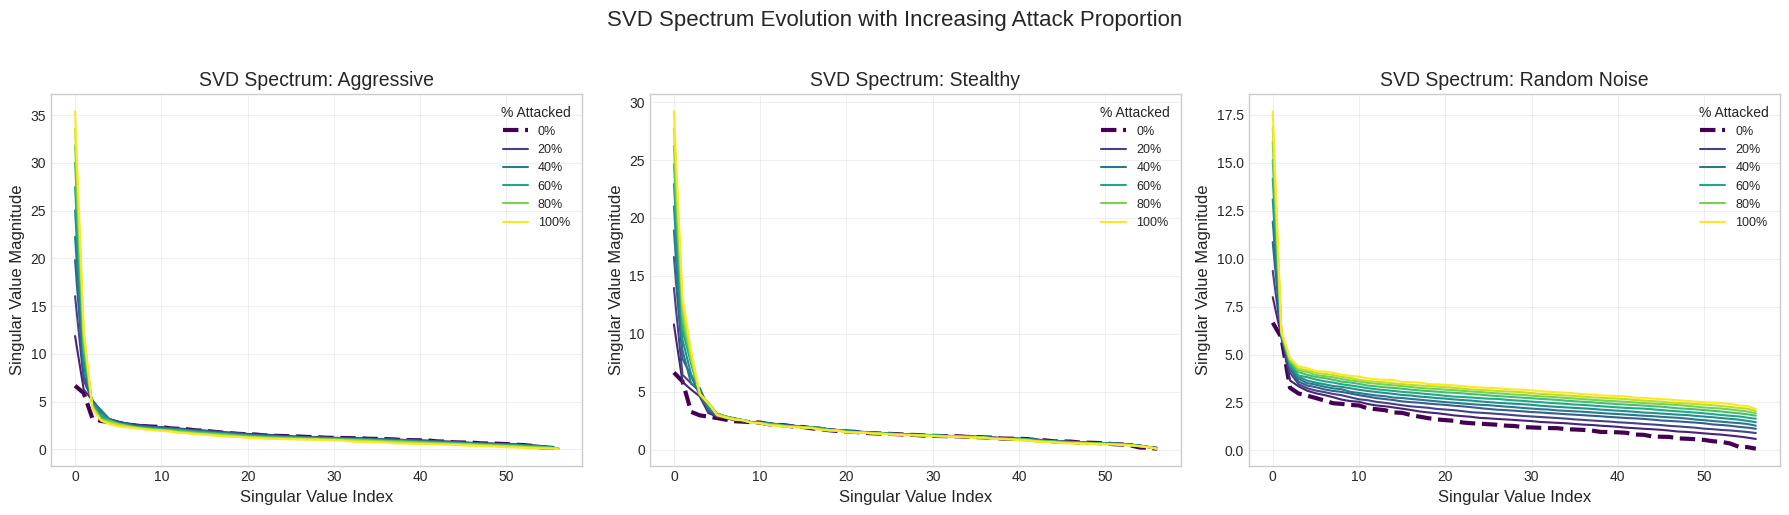

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(PROPORTIONS)))

for ax, (source_name, data) in zip(axes, results.items()):
    for i, (prop, sv) in enumerate(zip(data['proportions'], data['singular_values'])):
        label = f"{prop:.0%}" if i % 2 == 0 else None
        linewidth = 3 if prop == 0 else 1.5
        linestyle = '--' if prop == 0 else '-'
        ax.plot(sv, color=colors[i], label=label, linewidth=linewidth, linestyle=linestyle)
    
    ax.set_title(f'SVD Spectrum: {source_name.replace("_", " ").title()}', fontsize=14)
    ax.set_xlabel('Singular Value Index', fontsize=12)
    ax.set_ylabel('Singular Value Magnitude', fontsize=12)
    ax.legend(title='% Attacked', loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('SVD Spectrum Evolution with Increasing Attack Proportion', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../../outputs/svd_baseline/spambase/svd_spectrum_evolution_spambase.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.2 Metrics vs Proportion

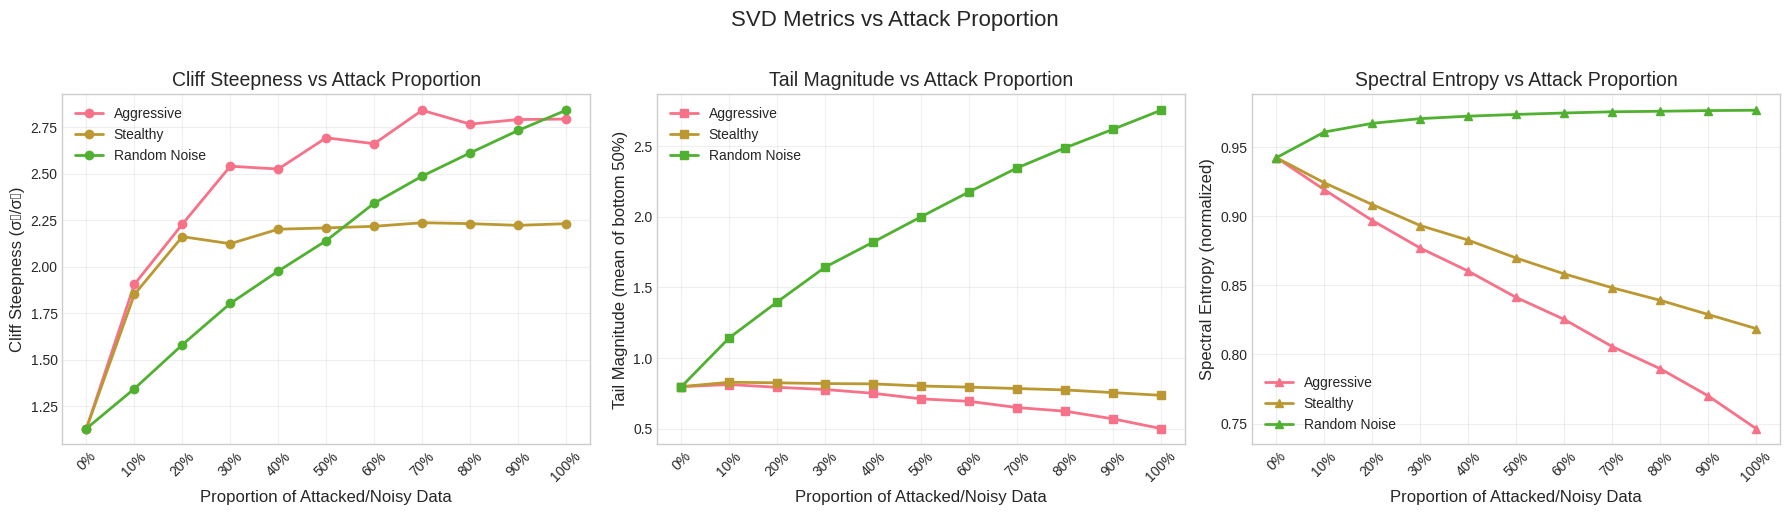

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax1 = axes[0]
for source_name, data in results.items():
    ax1.plot(data['proportions'], data['cliff_steepness'], 
             marker='o', label=source_name.replace('_', ' ').title(), linewidth=2)
ax1.set_xlabel('Proportion of Attacked/Noisy Data', fontsize=12)
ax1.set_ylabel('Cliff Steepness (σ₀/σ₁)', fontsize=12)
ax1.set_title('Cliff Steepness vs Attack Proportion', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xticks(PROPORTIONS)
ax1.set_xticklabels([f'{p:.0%}' for p in PROPORTIONS], rotation=45)

ax2 = axes[1]
for source_name, data in results.items():
    ax2.plot(data['proportions'], data['tail_magnitude'], 
             marker='s', label=source_name.replace('_', ' ').title(), linewidth=2)
ax2.set_xlabel('Proportion of Attacked/Noisy Data', fontsize=12)
ax2.set_ylabel('Tail Magnitude (mean of bottom 50%)', fontsize=12)
ax2.set_title('Tail Magnitude vs Attack Proportion', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks(PROPORTIONS)
ax2.set_xticklabels([f'{p:.0%}' for p in PROPORTIONS], rotation=45)

ax3 = axes[2]
for source_name, data in results.items():
    ax3.plot(data['proportions'], data['spectral_entropy'], 
             marker='^', label=source_name.replace('_', ' ').title(), linewidth=2)
ax3.set_xlabel('Proportion of Attacked/Noisy Data', fontsize=12)
ax3.set_ylabel('Spectral Entropy (normalized)', fontsize=12)
ax3.set_title('Spectral Entropy vs Attack Proportion', fontsize=14)
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_xticks(PROPORTIONS)
ax3.set_xticklabels([f'{p:.0%}' for p in PROPORTIONS], rotation=45)

plt.suptitle('SVD Metrics vs Attack Proportion', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../../outputs/svd_baseline/spambase/svd_metrics_vs_proportion_spambase.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.3 Original vs 100% Attacked

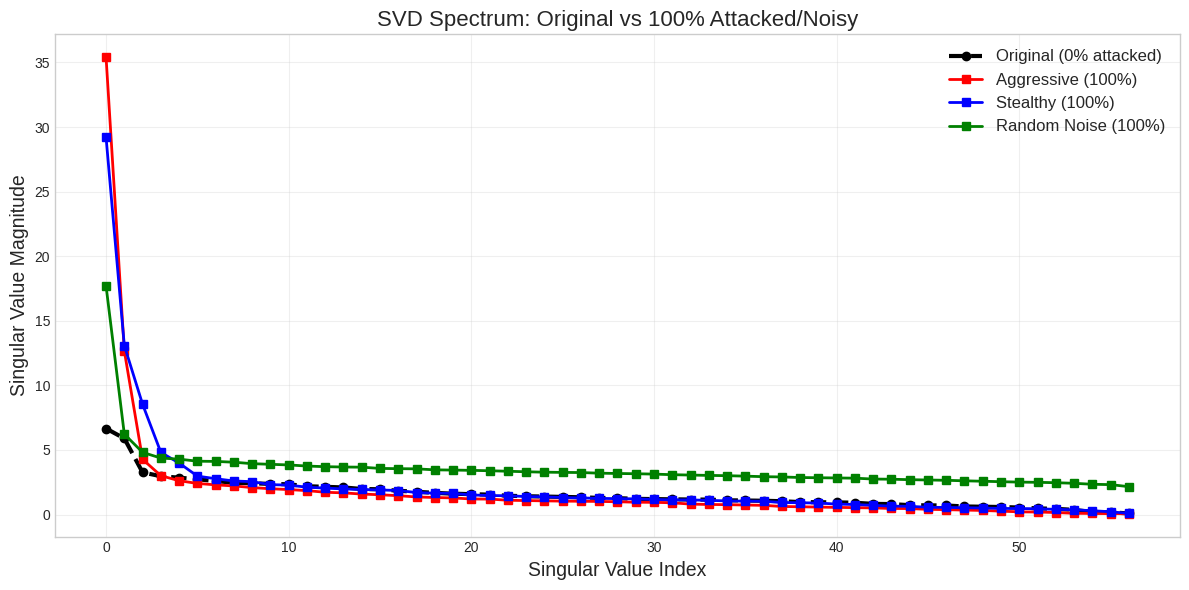

In [29]:
fig, ax = plt.subplots(figsize=(12, 6))

sv_original = results['aggressive']['singular_values'][0]
ax.plot(sv_original, 'k--', linewidth=3, label='Original (0% attacked)', marker='o')

colors = {'aggressive': 'red', 'stealthy': 'blue', 'random_noise': 'green'}
for source_name, data in results.items():
    sv_100 = data['singular_values'][-1]
    ax.plot(sv_100, color=colors[source_name], linewidth=2, 
            label=f'{source_name.replace("_", " ").title()} (100%)', marker='s')

ax.set_xlabel('Singular Value Index', fontsize=14)
ax.set_ylabel('Singular Value Magnitude', fontsize=14)
ax.set_title('SVD Spectrum: Original vs 100% Attacked/Noisy', fontsize=16)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../../outputs/svd_baseline/spambase/svd_original_vs_attacked_spambase.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.4 Singular Value Heatmap

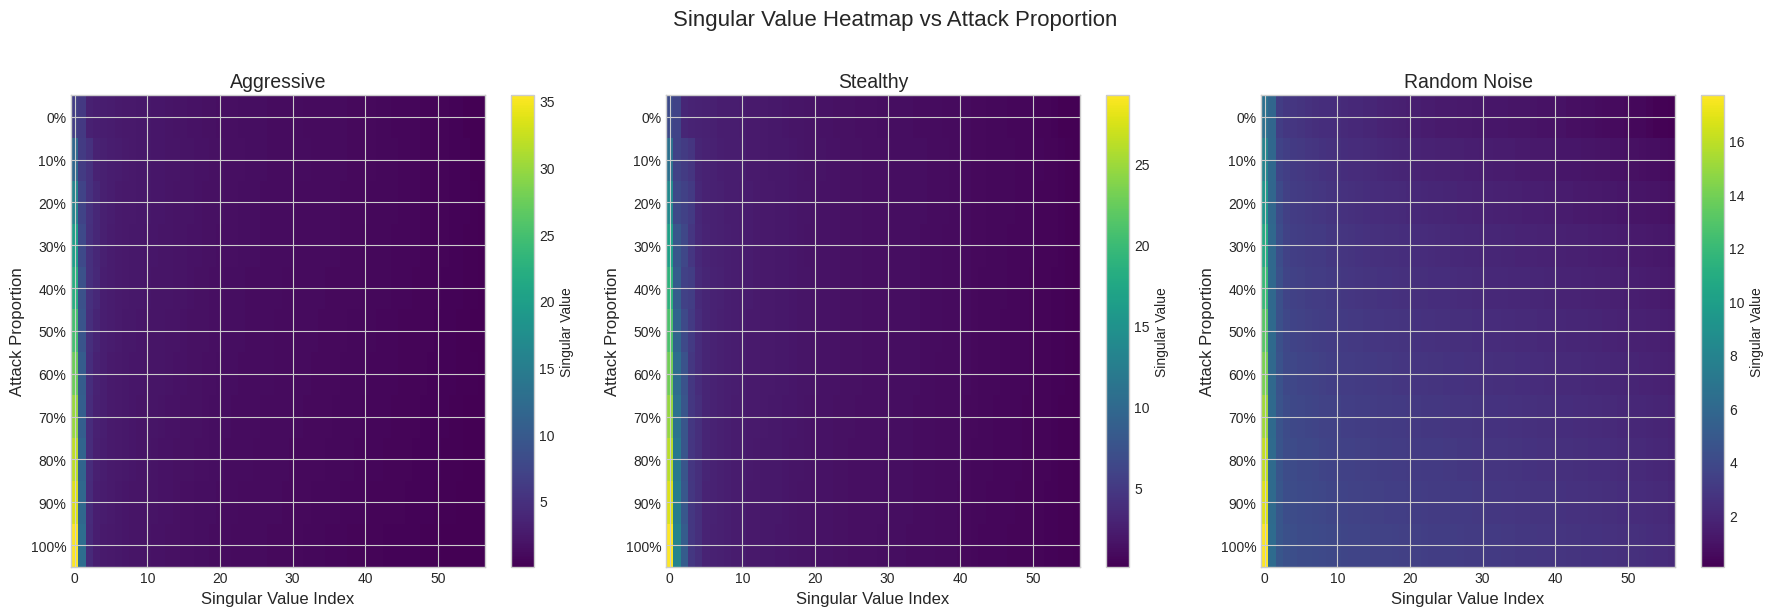

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (source_name, data) in zip(axes, results.items()):
    sv_matrix = np.array(data['singular_values'])
    
    im = ax.imshow(sv_matrix, aspect='auto', cmap='viridis')
    ax.set_xlabel('Singular Value Index', fontsize=12)
    ax.set_ylabel('Attack Proportion', fontsize=12)
    ax.set_title(f'{source_name.replace("_", " ").title()}', fontsize=14)
    ax.set_yticks(range(len(PROPORTIONS)))
    ax.set_yticklabels([f'{p:.0%}' for p in PROPORTIONS])
    plt.colorbar(im, ax=ax, label='Singular Value')

plt.suptitle('Singular Value Heatmap vs Attack Proportion', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../../outputs/svd_baseline/spambase/svd_heatmap_spambase.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary

In [31]:
print("=" * 80)
print("EXPERIMENT SUMMARY")
print("=" * 80)

print(f"\nDataset: Spambase ({N_SAMPLES} samples, {len(feature_names)} features)")
print(f"Attack: LowProFool (α={ALPHA}, iterations={MAXITERS})")
print(f"Trials per proportion: {N_TRIALS}")

print("\n" + "-" * 80)
print("ATTACK SUCCESS RATES:")
print("-" * 80)
for attack_type, rate in attack_success.items():
    print(f"  {attack_type:12s}: {rate:.2%}")

print("\n" + "-" * 80)
print("SVD METRIC CHANGES (0% → 100% attacked):")
print("-" * 80)

for source_name, data in results.items():
    cliff_change = data['cliff_steepness'][-1] - data['cliff_steepness'][0]
    tail_change = data['tail_magnitude'][-1] - data['tail_magnitude'][0]
    entropy_change = data['spectral_entropy'][-1] - data['spectral_entropy'][0]
    
    print(f"\n  {source_name.upper()}:")
    print(f"    Cliff steepness: {data['cliff_steepness'][0]:.3f} → {data['cliff_steepness'][-1]:.3f} (Δ={cliff_change:+.3f})")
    print(f"    Tail magnitude:  {data['tail_magnitude'][0]:.3f} → {data['tail_magnitude'][-1]:.3f} (Δ={tail_change:+.3f})")
    print(f"    Spectral entropy:{data['spectral_entropy'][0]:.3f} → {data['spectral_entropy'][-1]:.3f} (Δ={entropy_change:+.3f})")

print("\n" + "=" * 80)
print("HYPOTHESIS EVALUATION:")
print("=" * 80)
print("""
Hypothesis: Adding adversarial examples smooths the cliff and/or lifts the tail.

Observations to check:
1. Does cliff steepness DECREASE as attack proportion increases? (cliff smoothing)
2. Does tail magnitude INCREASE as attack proportion increases? (tail lifting)
3. Does spectral entropy INCREASE as attack proportion increases? (more spread out)
4. Is the effect more pronounced for aggressive vs stealthy attacks?
5. How does adversarial attack compare to random noise?
""")

EXPERIMENT SUMMARY

Dataset: Spambase (921 samples, 57 features)
Attack: LowProFool (α=0.1, iterations=300)
Trials per proportion: 5

--------------------------------------------------------------------------------
ATTACK SUCCESS RATES:
--------------------------------------------------------------------------------
  aggressive  : 100.00%
  stealthy    : 87.62%

--------------------------------------------------------------------------------
SVD METRIC CHANGES (0% → 100% attacked):
--------------------------------------------------------------------------------

  AGGRESSIVE:
    Cliff steepness: 1.130 → 2.795 (Δ=+1.665)
    Tail magnitude:  0.799 → 0.503 (Δ=-0.296)
    Spectral entropy:0.942 → 0.746 (Δ=-0.196)

  STEALTHY:
    Cliff steepness: 1.130 → 2.232 (Δ=+1.102)
    Tail magnitude:  0.799 → 0.738 (Δ=-0.061)
    Spectral entropy:0.942 → 0.819 (Δ=-0.124)

  RANDOM_NOISE:
    Cliff steepness: 1.130 → 2.843 (Δ=+1.712)
    Tail magnitude:  0.799 → 2.753 (Δ=+1.954)
    Spectral entro

In [32]:
print("\n" + "=" * 80)
print("CORRELATION CHECK:")
print("=" * 80)

for source_name, data in results.items():
    cliff = np.array(data['cliff_steepness'])
    tail = np.array(data['tail_magnitude'])
    props = np.array(data['proportions'])
    
    cliff_corr = np.corrcoef(props, cliff)[0, 1]
    tail_corr = np.corrcoef(props, tail)[0, 1]
    
    print(f"\n{source_name.upper()}:")
    print(f"  Cliff steepness correlation with proportion: {cliff_corr:+.3f}")
    print(f"    → {'SUPPORTS' if cliff_corr < -0.5 else 'WEAK/NO SUPPORT for'} 'cliff smoothing' hypothesis")
    print(f"  Tail magnitude correlation with proportion:  {tail_corr:+.3f}")
    print(f"    → {'SUPPORTS' if tail_corr > 0.5 else 'WEAK/NO SUPPORT for'} 'tail lifting' hypothesis")


CORRELATION CHECK:

AGGRESSIVE:
  Cliff steepness correlation with proportion: +0.826
    → WEAK/NO SUPPORT for 'cliff smoothing' hypothesis
  Tail magnitude correlation with proportion:  -0.966
    → WEAK/NO SUPPORT for 'tail lifting' hypothesis

STEALTHY:
  Cliff steepness correlation with proportion: +0.675
    → WEAK/NO SUPPORT for 'cliff smoothing' hypothesis
  Tail magnitude correlation with proportion:  -0.862
    → WEAK/NO SUPPORT for 'tail lifting' hypothesis

RANDOM_NOISE:
  Cliff steepness correlation with proportion: +0.993
    → WEAK/NO SUPPORT for 'cliff smoothing' hypothesis
  Tail magnitude correlation with proportion:  +0.990
    → SUPPORTS 'tail lifting' hypothesis


## 10. Save

In [33]:
import json

results_serializable = {}
for source_name, data in results.items():
    results_serializable[source_name] = {
        'proportions': [float(p) for p in data['proportions']],
        'singular_values': [sv.tolist() for sv in data['singular_values']],
        'cliff_steepness': [float(c) for c in data['cliff_steepness']],
        'tail_magnitude': [float(t) for t in data['tail_magnitude']],
        'spectral_entropy': [float(e) for e in data['spectral_entropy']]
    }

with open('../../outputs/svd_baseline/spambase/svd_analysis_results_spambase.json', 'w') as f:
    json.dump(results_serializable, f, indent=2)

print("Results saved to svd_analysis_results_spambase.json")
print("Figures saved as PNG files.")

Results saved to svd_analysis_results_spambase.json
Figures saved as PNG files.


## 11. K-Rank Approximation as a Defense

Hypothesis: If the adversarial perturbations really do live in the smaller singular components, then projecting the data down to a rank-k approximation (keeping only the top-k singular values) should strip out the attack.

In [34]:
def k_rank_approximation(data_matrix, k):
    """Truncated SVD: keep top-k singular values, zero out the rest."""
    U, s, Vh = svd(data_matrix, full_matrices=False)
    
    U_k = U[:, :k]
    s_k = s[:k]
    Vh_k = Vh[:k, :]
    
    approximated = U_k @ np.diag(s_k) @ Vh_k
    
    return approximated


def evaluate_attack_effectiveness(original_data, attacked_data, model, device):
    """Compare model predictions on original vs attacked data."""
    model.eval()
    
    with torch.no_grad():
        orig_tensor = torch.FloatTensor(original_data).to(device)
        original_preds = model(orig_tensor).argmax(dim=1).cpu().numpy()
        
        atk_tensor = torch.FloatTensor(attacked_data).to(device)
        attacked_preds = model(atk_tensor).argmax(dim=1).cpu().numpy()
    
    attack_success_rate = np.mean(original_preds != attacked_preds)
    
    return attack_success_rate, original_preds, attacked_preds


print("Helper functions defined.")

Helper functions defined.


In [35]:
n_features = original_data.shape[1]
K_VALUES = list(range(1, n_features + 1))

print(f"Testing k-rank approximation for k = 1 to {n_features}")
print(f"Original data shape: {original_data.shape}")
print(f"Number of test samples: {original_data.shape[0]}")

Testing k-rank approximation for k = 1 to 57
Original data shape: (921, 57)
Number of test samples: 921


In [36]:
k_rank_results = {
    'aggressive': {'k': [], 'attack_success_before': [], 'attack_success_after': [], 'restoration_rate': []},
    'stealthy': {'k': [], 'attack_success_before': [], 'attack_success_after': [], 'restoration_rate': []}
}

_, original_preds, _ = evaluate_attack_effectiveness(original_data, original_data, model, device)

print("Running k-rank approximation defense experiment...\n")

for attack_type in ['aggressive', 'stealthy']:
    print(f"--- {attack_type.upper()} Attack ---")
    attacked_data = adversarial_data[attack_type]
    
    attack_success_before, _, attacked_preds = evaluate_attack_effectiveness(
        original_data, attacked_data, model, device
    )
    print(f"Attack success rate (before defense): {attack_success_before:.2%}")
    
    for k in tqdm(K_VALUES, desc=f"K-rank ({attack_type})"):
        defended_data = k_rank_approximation(attacked_data, k)
        defended_data = np.clip(defended_data, bounds[0], bounds[1])
        
        attack_success_after, _, defended_preds = evaluate_attack_effectiveness(
            original_data, defended_data, model, device
        )
        
        successfully_attacked_mask = (original_preds != attacked_preds)
        if successfully_attacked_mask.sum() > 0:
            restored = (defended_preds[successfully_attacked_mask] == original_preds[successfully_attacked_mask])
            restoration_rate = restored.sum() / successfully_attacked_mask.sum()
        else:
            restoration_rate = 0.0
        
        k_rank_results[attack_type]['k'].append(k)
        k_rank_results[attack_type]['attack_success_before'].append(attack_success_before)
        k_rank_results[attack_type]['attack_success_after'].append(attack_success_after)
        k_rank_results[attack_type]['restoration_rate'].append(restoration_rate)
    
    print(f"Best restoration at k={k_rank_results[attack_type]['k'][np.argmax(k_rank_results[attack_type]['restoration_rate'])]}: "
          f"{max(k_rank_results[attack_type]['restoration_rate']):.2%}\n")

print("K-rank approximation experiment complete!")

Running k-rank approximation defense experiment...

--- AGGRESSIVE Attack ---
Attack success rate (before defense): 100.00%


K-rank (aggressive): 100%|██████████| 57/57 [00:00<00:00, 95.50it/s] 


Best restoration at k=1: 31.81%

--- STEALTHY Attack ---
Attack success rate (before defense): 87.62%


K-rank (stealthy): 100%|██████████| 57/57 [00:00<00:00, 90.26it/s] 

Best restoration at k=1: 49.69%

K-rank approximation experiment complete!


### 11.1 Defense Results

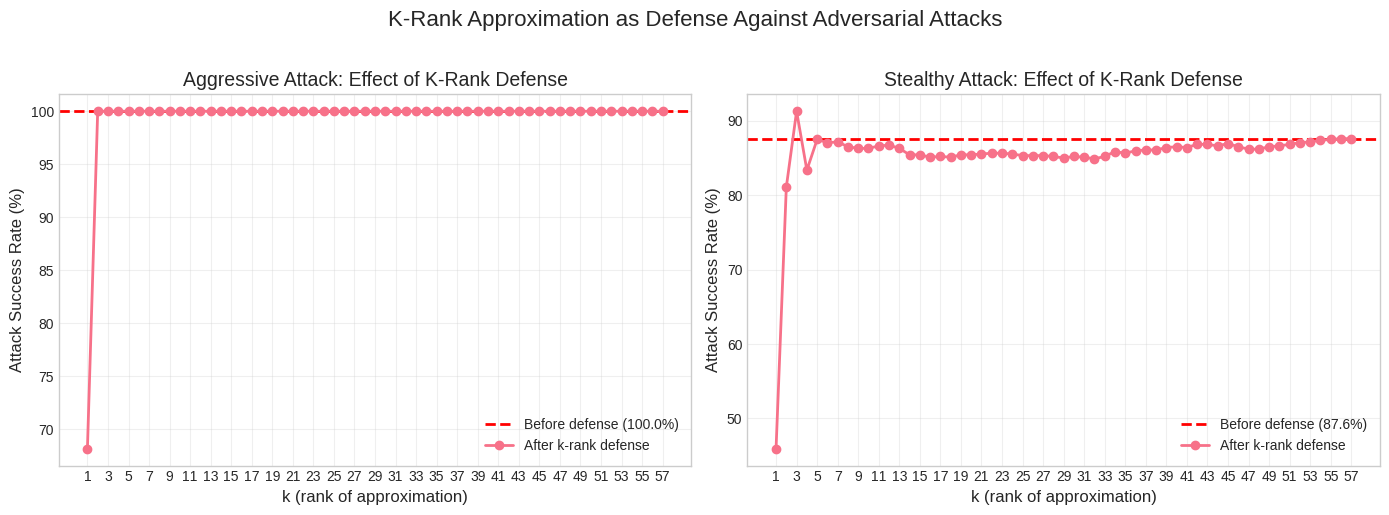

In [37]:
import os

output_dir = '../../outputs/svd_baseline/spambase/k_rank'
os.makedirs(output_dir, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, attack_type in zip(axes, ['aggressive', 'stealthy']):
    data = k_rank_results[attack_type]
    
    ax.axhline(y=data['attack_success_before'][0] * 100, color='red', linestyle='--', 
               label=f'Before defense ({data["attack_success_before"][0]:.1%})', linewidth=2)
    ax.plot(data['k'], np.array(data['attack_success_after']) * 100, 
            marker='o', linewidth=2, label='After k-rank defense')
    
    ax.set_xlabel('k (rank of approximation)', fontsize=12)
    ax.set_ylabel('Attack Success Rate (%)', fontsize=12)
    ax.set_title(f'{attack_type.title()} Attack: Effect of K-Rank Defense', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(K_VALUES[::2])

plt.suptitle('K-Rank Approximation as Defense Against Adversarial Attacks', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'k_rank_attack_success.png'), dpi=150, bbox_inches='tight')
plt.show()

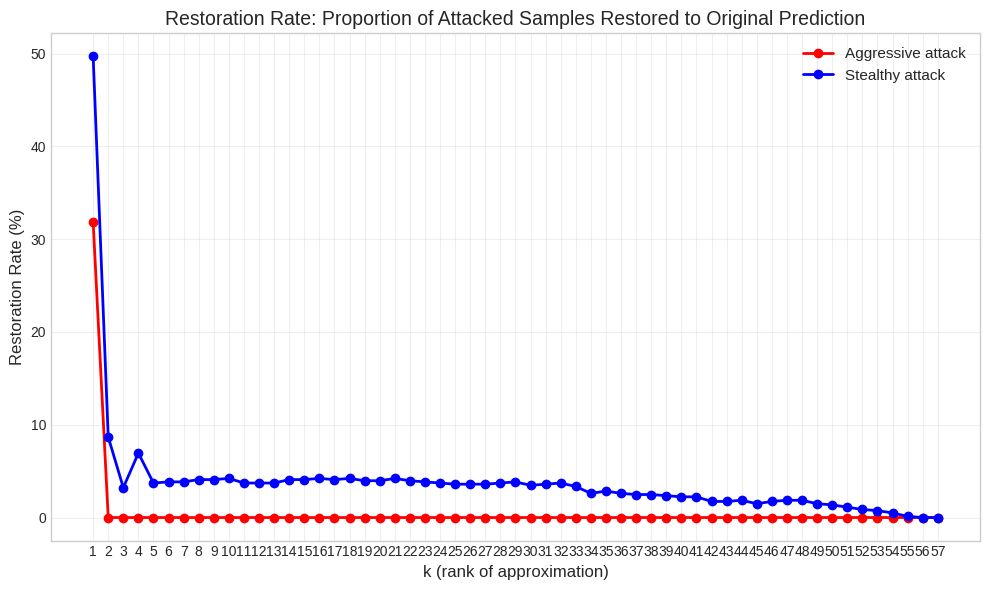

In [38]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = {'aggressive': 'red', 'stealthy': 'blue'}
for attack_type in ['aggressive', 'stealthy']:
    data = k_rank_results[attack_type]
    ax.plot(data['k'], np.array(data['restoration_rate']) * 100, 
            marker='o', linewidth=2, color=colors[attack_type],
            label=f'{attack_type.title()} attack')

ax.set_xlabel('k (rank of approximation)', fontsize=12)
ax.set_ylabel('Restoration Rate (%)', fontsize=12)
ax.set_title('Restoration Rate: Proportion of Attacked Samples Restored to Original Prediction', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xticks(K_VALUES)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'k_rank_restoration_rate.png'), dpi=150, bbox_inches='tight')
plt.show()

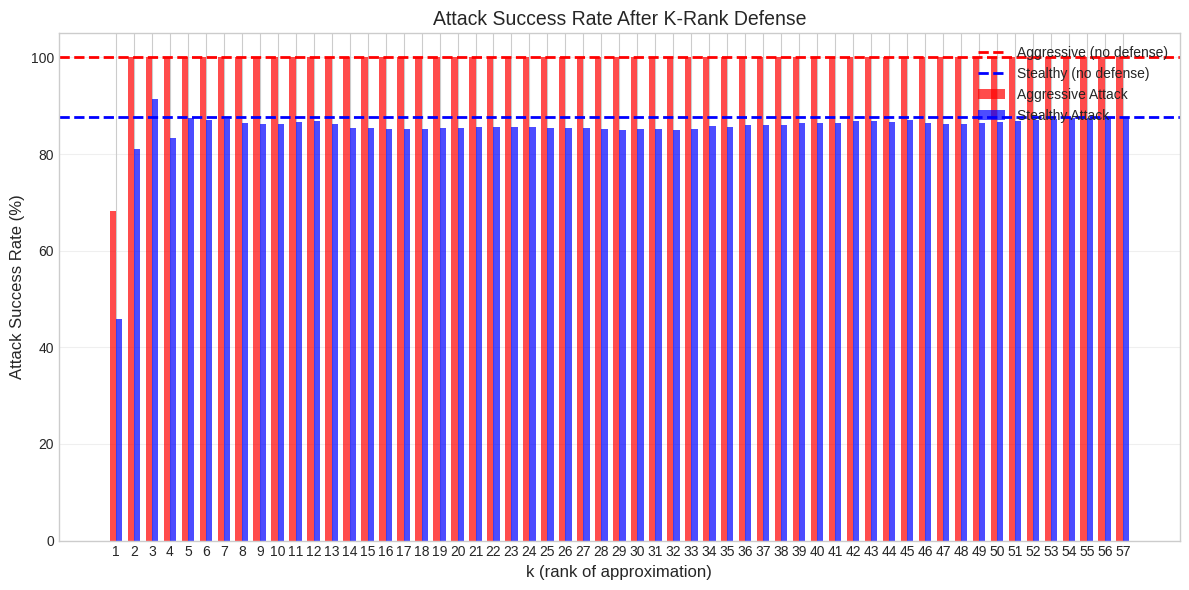

In [39]:
fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.35
x = np.arange(len(K_VALUES))

aggressive_after = np.array(k_rank_results['aggressive']['attack_success_after']) * 100
stealthy_after = np.array(k_rank_results['stealthy']['attack_success_after']) * 100

ax.bar(x - bar_width/2, aggressive_after, bar_width, label='Aggressive Attack', color='red', alpha=0.7)
ax.bar(x + bar_width/2, stealthy_after, bar_width, label='Stealthy Attack', color='blue', alpha=0.7)

ax.axhline(y=k_rank_results['aggressive']['attack_success_before'][0] * 100, 
           color='red', linestyle='--', linewidth=2, label='Aggressive (no defense)')
ax.axhline(y=k_rank_results['stealthy']['attack_success_before'][0] * 100, 
           color='blue', linestyle='--', linewidth=2, label='Stealthy (no defense)')

ax.set_xlabel('k (rank of approximation)', fontsize=12)
ax.set_ylabel('Attack Success Rate (%)', fontsize=12)
ax.set_title('Attack Success Rate After K-Rank Defense', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(K_VALUES)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'k_rank_comparison_bar.png'), dpi=150, bbox_inches='tight')
plt.show()

### 11.2 Finding the Best K

In [40]:
print("=" * 70)
print("K-RANK APPROXIMATION DEFENSE ANALYSIS")
print("=" * 70)

for attack_type in ['aggressive', 'stealthy']:
    data = k_rank_results[attack_type]
    
    best_k_restoration = data['k'][np.argmax(data['restoration_rate'])]
    best_restoration = max(data['restoration_rate'])
    
    best_k_defense = data['k'][np.argmin(data['attack_success_after'])]
    best_defense = min(data['attack_success_after'])
    
    print(f"\n{attack_type.upper()} ATTACK:")
    print(f"  Original attack success rate: {data['attack_success_before'][0]:.2%}")
    print(f"  Best k for restoration: k={best_k_restoration} (restores {best_restoration:.2%} of attacked samples)")
    print(f"  Best k for defense: k={best_k_defense} (reduces attack success to {best_defense:.2%})")
    print(f"  Attack success at full rank (k={n_features}): {data['attack_success_after'][-1]:.2%}")

print("\n" + "=" * 70)
print("INTERPRETATION:")
print("=" * 70)
print("""
- If low-k approximation reduces attack success, adversarial perturbations
  lie primarily in the noise subspace (smaller singular values).
- If attack success remains high even at low k, the perturbations are
  aligned with the data's principal components.
- The optimal k balances defense effectiveness with data preservation.
""")

K-RANK APPROXIMATION DEFENSE ANALYSIS

AGGRESSIVE ATTACK:
  Original attack success rate: 100.00%
  Best k for restoration: k=1 (restores 31.81% of attacked samples)
  Best k for defense: k=1 (reduces attack success to 68.19%)
  Attack success at full rank (k=57): 100.00%

STEALTHY ATTACK:
  Original attack success rate: 87.62%
  Best k for restoration: k=1 (restores 49.69% of attacked samples)
  Best k for defense: k=1 (reduces attack success to 45.93%)
  Attack success at full rank (k=57): 87.62%

INTERPRETATION:

- If low-k approximation reduces attack success, adversarial perturbations
  lie primarily in the noise subspace (smaller singular values).
- If attack success remains high even at low k, the perturbations are
  aligned with the data's principal components.
- The optimal k balances defense effectiveness with data preservation.



In [41]:
k_rank_results_serializable = {}
for attack_type, data in k_rank_results.items():
    k_rank_results_serializable[attack_type] = {
        'k': data['k'],
        'attack_success_before': [float(x) for x in data['attack_success_before']],
        'attack_success_after': [float(x) for x in data['attack_success_after']],
        'restoration_rate': [float(x) for x in data['restoration_rate']]
    }

with open(os.path.join(output_dir, 'k_rank_defense_results.json'), 'w') as f:
    json.dump(k_rank_results_serializable, f, indent=2)

print(f"Results saved to {output_dir}/k_rank_defense_results.json")
print(f"Plots saved to {output_dir}/")

Results saved to k_rank_results_spambase/k_rank_defense_results.json
Plots saved to k_rank_results_spambase/


### 11.3 Accuracy Trade-off

In [42]:
y_test_subset = y_test[:N_SAMPLES].cpu().numpy()
y_true = y_test_subset.argmax(axis=1)

accuracy_results = {'k': [], 'original_accuracy': [], 'defended_aggressive_accuracy': [], 'defended_stealthy_accuracy': []}

with torch.no_grad():
    orig_tensor = torch.FloatTensor(original_data).to(device)
    orig_preds = model(orig_tensor).argmax(dim=1).cpu().numpy()
original_accuracy = (orig_preds == y_true).mean()

print(f"Original model accuracy on test set: {original_accuracy:.2%}\n")

for k in tqdm(K_VALUES, desc="Accuracy analysis"):
    accuracy_results['k'].append(k)
    
    clean_approx = k_rank_approximation(original_data, k)
    clean_approx = np.clip(clean_approx, bounds[0], bounds[1])
    
    with torch.no_grad():
        clean_tensor = torch.FloatTensor(clean_approx).to(device)
        clean_preds = model(clean_tensor).argmax(dim=1).cpu().numpy()
    accuracy_results['original_accuracy'].append((clean_preds == y_true).mean())
    
    agg_approx = k_rank_approximation(adversarial_data['aggressive'], k)
    agg_approx = np.clip(agg_approx, bounds[0], bounds[1])
    with torch.no_grad():
        agg_tensor = torch.FloatTensor(agg_approx).to(device)
        agg_preds = model(agg_tensor).argmax(dim=1).cpu().numpy()
    accuracy_results['defended_aggressive_accuracy'].append((agg_preds == y_true).mean())
    
    stl_approx = k_rank_approximation(adversarial_data['stealthy'], k)
    stl_approx = np.clip(stl_approx, bounds[0], bounds[1])
    with torch.no_grad():
        stl_tensor = torch.FloatTensor(stl_approx).to(device)
        stl_preds = model(stl_tensor).argmax(dim=1).cpu().numpy()
    accuracy_results['defended_stealthy_accuracy'].append((stl_preds == y_true).mean())

print("Accuracy analysis complete!")

Original model accuracy on test set: 90.45%



Accuracy analysis: 100%|██████████| 57/57 [00:00<00:00, 57.09it/s]

Accuracy analysis complete!


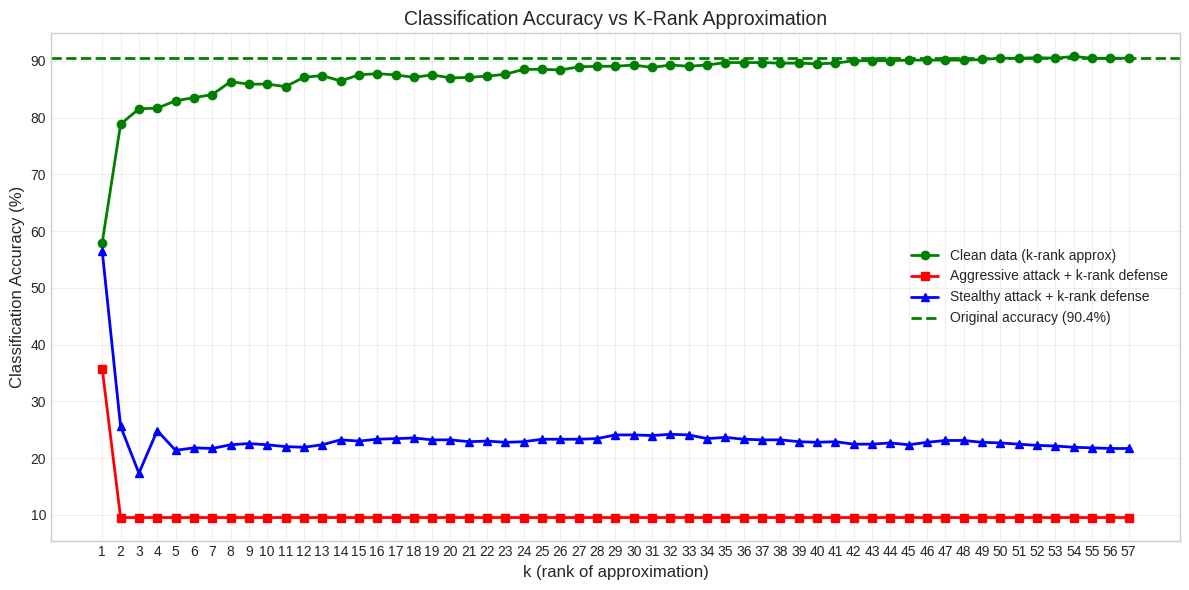


All k-rank analysis plots saved to k_rank_results_spambase/


In [43]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(accuracy_results['k'], np.array(accuracy_results['original_accuracy']) * 100, 
        marker='o', linewidth=2, color='green', label='Clean data (k-rank approx)')
ax.plot(accuracy_results['k'], np.array(accuracy_results['defended_aggressive_accuracy']) * 100, 
        marker='s', linewidth=2, color='red', label='Aggressive attack + k-rank defense')
ax.plot(accuracy_results['k'], np.array(accuracy_results['defended_stealthy_accuracy']) * 100, 
        marker='^', linewidth=2, color='blue', label='Stealthy attack + k-rank defense')

ax.axhline(y=original_accuracy * 100, color='green', linestyle='--', 
           label=f'Original accuracy ({original_accuracy:.1%})', linewidth=2)

ax.set_xlabel('k (rank of approximation)', fontsize=12)
ax.set_ylabel('Classification Accuracy (%)', fontsize=12)
ax.set_title('Classification Accuracy vs K-Rank Approximation', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(K_VALUES)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'k_rank_accuracy.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAll k-rank analysis plots saved to {output_dir}/")

## 12. Varying the Attack Percentage

 Hypothesis: when everything is attacked, SVD just learns the “attacked” subspace. If there are clean samples mixed in, they might anchor the SVD toward the real data structure and make the defense work better.

Sweeping attack percentage from 5% to 100% to test.

In [44]:
ATTACK_PERCENTAGES = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.0]
K_VALUES_TO_TEST = [1, 2, 3, 5, 10, 15, 20, 30, 40, 50, n_features]
N_TRIALS = 3

print("Experiment: K-Rank Defense with Varying Attack Percentages")
print(f"Attack percentages: {[f'{p:.0%}' for p in ATTACK_PERCENTAGES]}")
print(f"K values to test: {K_VALUES_TO_TEST}")
print(f"Trials per configuration: {N_TRIALS}")

Experiment: K-Rank Defense with Varying Attack Percentages
Attack percentages: ['5%', '10%', '20%', '30%', '40%', '50%', '60%', '70%', '80%', '90%', '100%']
K values to test: [1, 2, 3, 5, 10, 15, 20, 30, 40, 50, 57]
Trials per configuration: 3


In [45]:
def run_mixed_defense_experiment(original_data, attacked_data, attack_pct, k, model, device, bounds, seed=42):
    """K-rank defense on mixed (clean + attacked) data. SVD sees the mixture,
    so clean points can anchor the subspace toward real structure."""
    np.random.seed(seed)
    n_samples = original_data.shape[0]
    n_attacked = int(n_samples * attack_pct)
    
    attack_indices = np.random.choice(n_samples, n_attacked, replace=False)
    attack_mask = np.zeros(n_samples, dtype=bool)
    attack_mask[attack_indices] = True
    
    mixed_data = original_data.copy()
    mixed_data[attack_mask] = attacked_data[attack_mask]
    
    defended_data = k_rank_approximation(mixed_data, k)
    defended_data = np.clip(defended_data, bounds[0], bounds[1])
    
    model.eval()
    with torch.no_grad():
        orig_tensor = torch.FloatTensor(original_data).to(device)
        original_preds = model(orig_tensor).argmax(dim=1).cpu().numpy()
        
        mixed_tensor = torch.FloatTensor(mixed_data).to(device)
        mixed_preds = model(mixed_tensor).argmax(dim=1).cpu().numpy()
        
        defended_tensor = torch.FloatTensor(defended_data).to(device)
        defended_preds = model(defended_tensor).argmax(dim=1).cpu().numpy()
    
    attacked_original_preds = original_preds[attack_mask]
    attacked_mixed_preds = mixed_preds[attack_mask]
    attacked_defended_preds = defended_preds[attack_mask]
    
    attack_success_before = (attacked_original_preds != attacked_mixed_preds).mean()
    attack_success_after = (attacked_original_preds != attacked_defended_preds).mean()
    
    successfully_attacked = (attacked_original_preds != attacked_mixed_preds)
    if successfully_attacked.sum() > 0:
        restored = (attacked_defended_preds[successfully_attacked] == attacked_original_preds[successfully_attacked])
        restoration_rate = restored.mean()
    else:
        restoration_rate = 0.0
    
    y_true = y_test[:N_SAMPLES].cpu().numpy().argmax(axis=1)
    accuracy_after_defense = (defended_preds == y_true).mean()
    
    return {
        'attack_success_before': attack_success_before,
        'attack_success_after': attack_success_after,
        'restoration_rate': restoration_rate,
        'accuracy': accuracy_after_defense
    }

print("Mixed defense experiment function defined.")

Mixed defense experiment function defined.


In [46]:
print("Running experiment for AGGRESSIVE attack...\n")

mixed_results_aggressive = []

for attack_pct in tqdm(ATTACK_PERCENTAGES, desc="Attack %"):
    for k in K_VALUES_TO_TEST:
        trial_results = []
        for trial in range(N_TRIALS):
            result = run_mixed_defense_experiment(
                original_data, 
                adversarial_data['aggressive'],
                attack_pct, k, model, device, bounds,
                seed=trial * 100 + int(attack_pct * 100)
            )
            trial_results.append(result)
        
        avg_result = {
            'attack_pct': attack_pct,
            'k': k,
            'attack_success_before': np.mean([r['attack_success_before'] for r in trial_results]),
            'attack_success_after': np.mean([r['attack_success_after'] for r in trial_results]),
            'restoration_rate': np.mean([r['restoration_rate'] for r in trial_results]),
            'accuracy': np.mean([r['accuracy'] for r in trial_results])
        }
        mixed_results_aggressive.append(avg_result)

df_aggressive = pd.DataFrame(mixed_results_aggressive)
print("\nAggressive attack experiment complete!")
print(df_aggressive.head(10))

Running experiment for AGGRESSIVE attack...



Attack %: 100%|██████████| 11/11 [00:05<00:00,  2.02it/s]


Aggressive attack experiment complete!
   attack_pct   k  attack_success_before  attack_success_after  \
0        0.05   1                    1.0              0.579710   
1        0.05   2                    1.0              0.891304   
2        0.05   3                    1.0              0.978261   
3        0.05   5                    1.0              1.000000   
4        0.05  10                    1.0              1.000000   
5        0.05  15                    1.0              1.000000   
6        0.05  20                    1.0              1.000000   
7        0.05  30                    1.0              1.000000   
8        0.05  40                    1.0              1.000000   
9        0.05  50                    1.0              1.000000   

   restoration_rate  accuracy  
0          0.420290  0.671734  
1          0.108696  0.828447  
2          0.021739  0.829171  
3          0.000000  0.837857  
4          0.000000  0.850887  
5          0.000000  0.848353  
6        

In [47]:
print("Running experiment for STEALTHY attack...\n")

mixed_results_stealthy = []

for attack_pct in tqdm(ATTACK_PERCENTAGES, desc="Attack %"):
    for k in K_VALUES_TO_TEST:
        trial_results = []
        for trial in range(N_TRIALS):
            result = run_mixed_defense_experiment(
                original_data, 
                adversarial_data['stealthy'],
                attack_pct, k, model, device, bounds,
                seed=trial * 100 + int(attack_pct * 100)
            )
            trial_results.append(result)
        
        avg_result = {
            'attack_pct': attack_pct,
            'k': k,
            'attack_success_before': np.mean([r['attack_success_before'] for r in trial_results]),
            'attack_success_after': np.mean([r['attack_success_after'] for r in trial_results]),
            'restoration_rate': np.mean([r['restoration_rate'] for r in trial_results]),
            'accuracy': np.mean([r['accuracy'] for r in trial_results])
        }
        mixed_results_stealthy.append(avg_result)

df_stealthy = pd.DataFrame(mixed_results_stealthy)
print("\nStealthy attack experiment complete!")
print(df_stealthy.head(10))

Running experiment for STEALTHY attack...



Attack %: 100%|██████████| 11/11 [00:05<00:00,  2.08it/s]


Stealthy attack experiment complete!
   attack_pct   k  attack_success_before  attack_success_after  \
0        0.05   1               0.862319              0.572464   
1        0.05   2               0.862319              0.500000   
2        0.05   3               0.862319              0.731884   
3        0.05   5               0.862319              0.797101   
4        0.05  10               0.862319              0.724638   
5        0.05  15               0.862319              0.731884   
6        0.05  20               0.862319              0.775362   
7        0.05  30               0.862319              0.804348   
8        0.05  40               0.862319              0.811594   
9        0.05  50               0.862319              0.840580   

   restoration_rate  accuracy  
0          0.487365  0.597539  
1          0.521644  0.684401  
2          0.148978  0.778502  
3          0.074929  0.780311  
4          0.157987  0.835324  
5          0.150736  0.845820  
6          

### 12.1 Attack % vs Defense Effectiveness

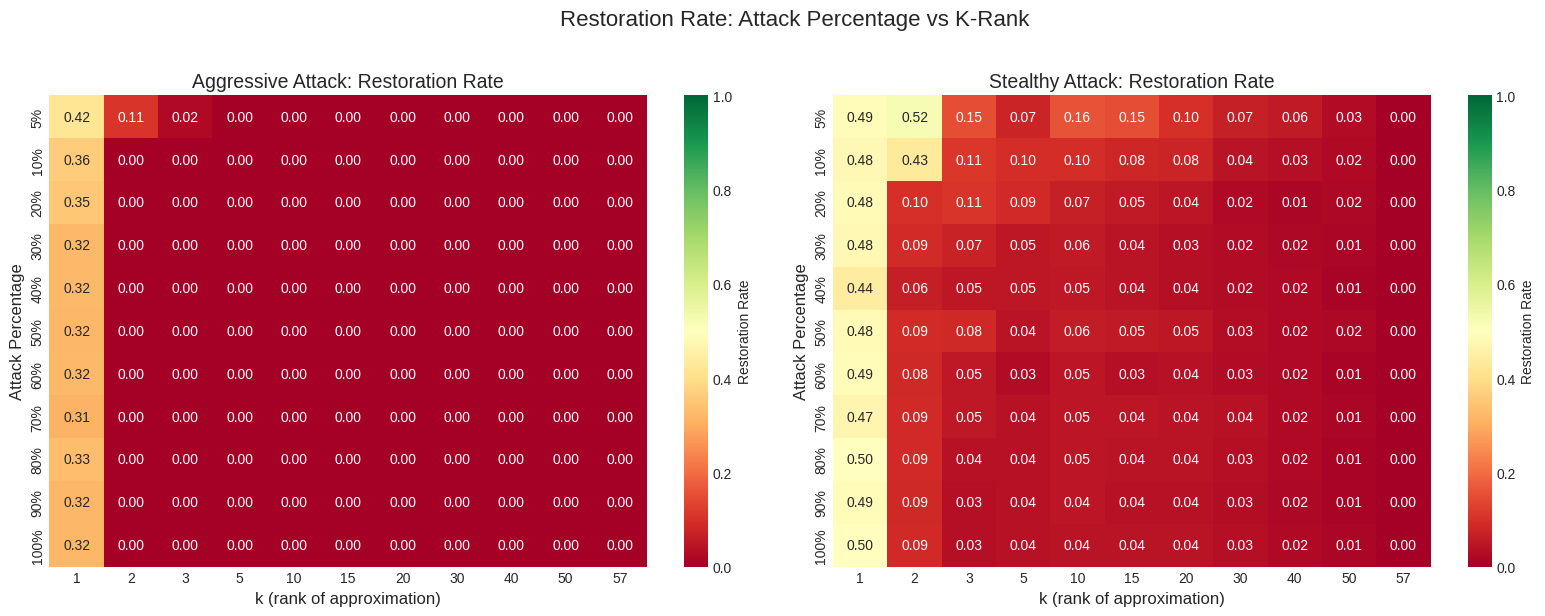

In [48]:
output_dir_mixed = '../../outputs/svd_baseline/spambase/k_rank/varying_attack_pct'
os.makedirs(output_dir_mixed, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (df, title) in zip(axes, [(df_aggressive, 'Aggressive Attack'), (df_stealthy, 'Stealthy Attack')]):
    pivot = df.pivot(index='attack_pct', columns='k', values='restoration_rate')
    sns.heatmap(pivot, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn', 
                vmin=0, vmax=1, cbar_kws={'label': 'Restoration Rate'})
    ax.set_xlabel('k (rank of approximation)', fontsize=12)
    ax.set_ylabel('Attack Percentage', fontsize=12)
    ax.set_title(f'{title}: Restoration Rate', fontsize=14)
    ax.set_yticklabels([f'{float(t.get_text()):.0%}' for t in ax.get_yticklabels()])

plt.suptitle('Restoration Rate: Attack Percentage vs K-Rank', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(output_dir_mixed, 'heatmap_restoration_rate.png'), dpi=150, bbox_inches='tight')
plt.show()

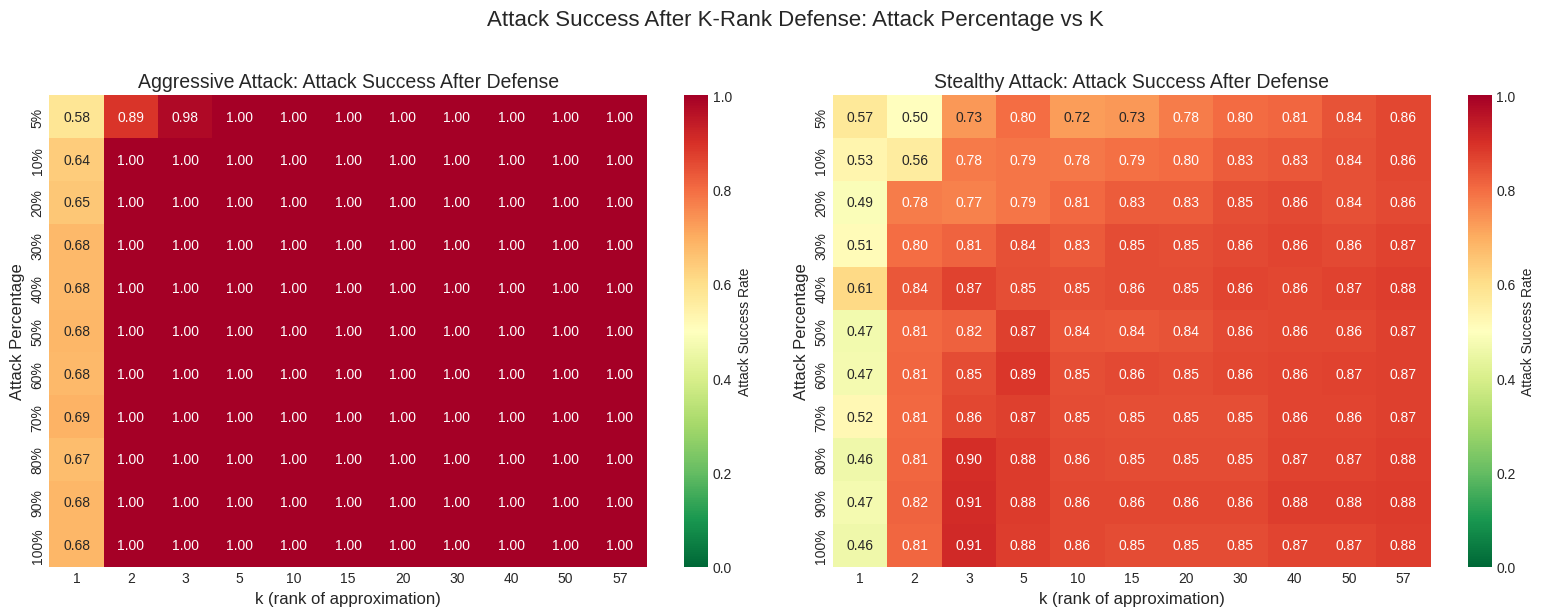

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (df, title) in zip(axes, [(df_aggressive, 'Aggressive Attack'), (df_stealthy, 'Stealthy Attack')]):
    pivot = df.pivot(index='attack_pct', columns='k', values='attack_success_after')
    sns.heatmap(pivot, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn_r', 
                vmin=0, vmax=1, cbar_kws={'label': 'Attack Success Rate'})
    ax.set_xlabel('k (rank of approximation)', fontsize=12)
    ax.set_ylabel('Attack Percentage', fontsize=12)
    ax.set_title(f'{title}: Attack Success After Defense', fontsize=14)
    ax.set_yticklabels([f'{float(t.get_text()):.0%}' for t in ax.get_yticklabels()])

plt.suptitle('Attack Success After K-Rank Defense: Attack Percentage vs K', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(output_dir_mixed, 'heatmap_attack_success.png'), dpi=150, bbox_inches='tight')
plt.show()

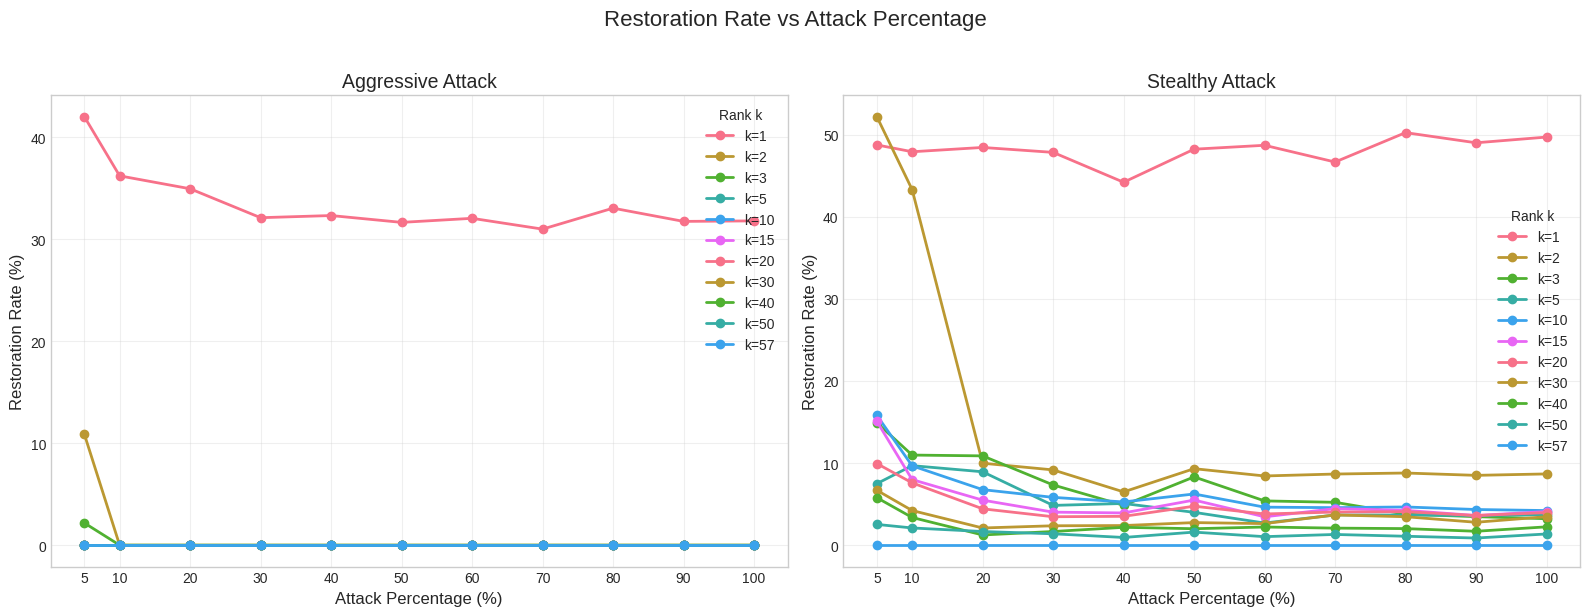

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (df, title) in zip(axes, [(df_aggressive, 'Aggressive Attack'), (df_stealthy, 'Stealthy Attack')]):
    for k in K_VALUES_TO_TEST:
        subset = df[df['k'] == k]
        ax.plot(subset['attack_pct'] * 100, subset['restoration_rate'] * 100, 
                marker='o', label=f'k={k}', linewidth=2)
    
    ax.set_xlabel('Attack Percentage (%)', fontsize=12)
    ax.set_ylabel('Restoration Rate (%)', fontsize=12)
    ax.set_title(f'{title}', fontsize=14)
    ax.legend(title='Rank k', loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_xticks([p * 100 for p in ATTACK_PERCENTAGES])

plt.suptitle('Restoration Rate vs Attack Percentage', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(output_dir_mixed, 'lineplot_restoration_vs_attack_pct.png'), dpi=150, bbox_inches='tight')
plt.show()

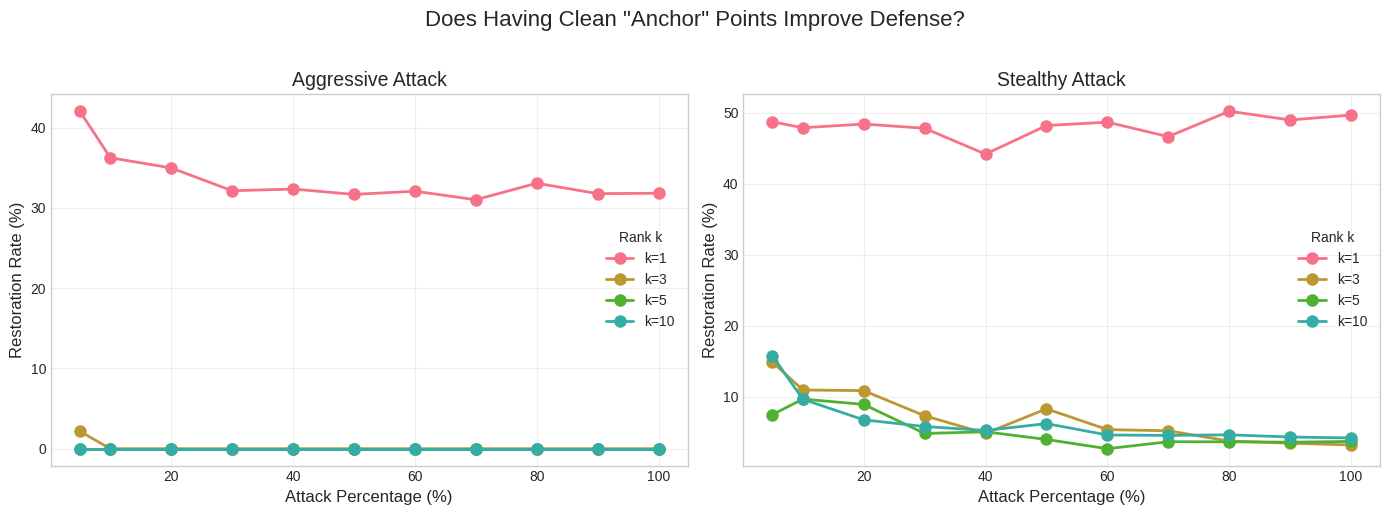

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
k_focus = [1, 3, 5, 10]

for ax, (df, title) in zip(axes, [(df_aggressive, 'Aggressive'), (df_stealthy, 'Stealthy')]):
    for k in k_focus:
        subset = df[df['k'] == k]
        ax.plot(subset['attack_pct'] * 100, subset['restoration_rate'] * 100, 
                marker='o', label=f'k={k}', linewidth=2, markersize=8)
    
    ax.set_xlabel('Attack Percentage (%)', fontsize=12)
    ax.set_ylabel('Restoration Rate (%)', fontsize=12)
    ax.set_title(f'{title} Attack', fontsize=14)
    ax.legend(title='Rank k')
    ax.grid(True, alpha=0.3)

plt.suptitle('Does Having Clean "Anchor" Points Improve Defense?', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(output_dir_mixed, 'anchor_points_effect.png'), dpi=150, bbox_inches='tight')
plt.show()

### 12.2 Results

In [52]:
print("=" * 80)
print("SUMMARY: EFFECT OF ATTACK PERCENTAGE ON K-RANK DEFENSE")
print("=" * 80)

print("\n" + "-" * 80)
print("KEY QUESTION: Does having clean 'anchor' points improve defense effectiveness?")
print("-" * 80)

for attack_type, df in [('Aggressive', df_aggressive), ('Stealthy', df_stealthy)]:
    print(f"\n{attack_type.upper()} ATTACK:")
    print(f"{'Attack %':<12} {'k=1 Restore':<15} {'k=3 Restore':<15} {'k=5 Restore':<15}")
    print("-" * 60)
    
    for pct in [0.05, 0.10, 0.20, 0.50, 1.0]:
        row_k1 = df[(df['attack_pct'] == pct) & (df['k'] == 1)]['restoration_rate'].values
        row_k3 = df[(df['attack_pct'] == pct) & (df['k'] == 3)]['restoration_rate'].values
        row_k5 = df[(df['attack_pct'] == pct) & (df['k'] == 5)]['restoration_rate'].values
        
        k1_val = f"{row_k1[0]:.1%}" if len(row_k1) > 0 else "N/A"
        k3_val = f"{row_k3[0]:.1%}" if len(row_k3) > 0 else "N/A"
        k5_val = f"{row_k5[0]:.1%}" if len(row_k5) > 0 else "N/A"
        
        print(f"{pct:<12.0%} {k1_val:<15} {k3_val:<15} {k5_val:<15}")

print("\n" + "=" * 80)
print("INTERPRETATION:")
print("=" * 80)
print("""
If restoration rate INCREASES as attack percentage DECREASES:
  → Clean anchor points help SVD discover the true data structure
  → The defense becomes more effective with fewer attacks

If restoration rate stays SIMILAR regardless of attack percentage:
  → Clean anchor points don't significantly help
  → The defense effectiveness is independent of attack density
""")

SUMMARY: EFFECT OF ATTACK PERCENTAGE ON K-RANK DEFENSE

--------------------------------------------------------------------------------
KEY QUESTION: Does having clean 'anchor' points improve defense effectiveness?
--------------------------------------------------------------------------------

AGGRESSIVE ATTACK:
Attack %     k=1 Restore     k=3 Restore     k=5 Restore    
------------------------------------------------------------
5%           42.0%           2.2%            0.0%           
10%          36.2%           0.0%            0.0%           
20%          35.0%           0.0%            0.0%           
50%          31.7%           0.0%            0.0%           
100%         31.8%           0.0%            0.0%           

STEALTHY ATTACK:
Attack %     k=1 Restore     k=3 Restore     k=5 Restore    
------------------------------------------------------------
5%           48.7%           14.9%           7.5%           
10%          47.9%           11.0%           9.7%      

In [53]:
mixed_results_all = {
    'aggressive': df_aggressive.to_dict('records'),
    'stealthy': df_stealthy.to_dict('records')
}

with open(os.path.join(output_dir_mixed, 'varying_attack_pct_results.json'), 'w') as f:
    json.dump(mixed_results_all, f, indent=2)

print(f"Results saved to {output_dir_mixed}/varying_attack_pct_results.json")
print(f"Plots saved to {output_dir_mixed}/")

Results saved to k_rank_results_spambase/varying_attack_pct/varying_attack_pct_results.json
Plots saved to k_rank_results_spambase/varying_attack_pct/
